In [1]:
from dataclasses import dataclass
import numpy as np
import os
import random
import torch
from torch import optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

if not os.path.exists("./KuiSCIMA"):
    !git clone https://github.com/SuziAI/KuiSCIMA.git
if not os.path.exists("./gui-tools"):
    !git clone https://github.com/SuziAI/gui-tools.git

from data_extraction import *
from image_manipulation import *
from model import *
from suzipu import *

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib import cm

BATCH_SIZE = 100

total_dataset = open_suzipu_dataset("./TotalDataset/Music/")
total_dataset = get_cropped_dataset(total_dataset)

In [2]:
def normalize():
    return transforms.Normalize(mean=0.7102, std=0.0914)
    
def get_validation_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    validation_transforms = transforms.Compose([
        transforms.ToTensor(),
        shrink(is_random=False, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        normalize(), # normalize mean and variance
    ])
    return validation_transforms

display_transforms = transforms.Compose([
    transforms.ToTensor(),
    shrink(is_random=False, target_size=40),
    paste_to_square(is_random=False, target_size=45),
])

In [3]:
pitch_model = TemperatureScalingCalibrationModule(CnnModel(11))
pitch_model.load_state_dict(torch.load("./suzi_model_pitch.std"))
pitch_model.eval()
secondary_model = TemperatureScalingCalibrationModule(CnnModel(7))
secondary_model.load_state_dict(torch.load("./suzi_model_secondary.std"))
secondary_model.eval()

TemperatureScalingCalibrationModule(
  (model): CnnModel(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc1): Linear(in_features=4608, out_features=128, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc2): Linear(in_features=128, out_features=7, bias=True)
    (logits): LogSoftmax(dim=1)
  )
)

In [4]:
import umap
import pickle

def get_features(model, l):
    return model.model.get_representation(l)

def get_feature_dataset(dataset):
    class Dataset(torch.utils.data.Dataset):
        def __init__(self, return_pitch, dataset: list, model=None, tf=None):
            model.eval()
            concatenation = torch.cat([tf(entry["image"]).unsqueeze(0) for entry in dataset])
            
            self.X = get_features(model, concatenation)
            self.original = [entry["image"] for entry in dataset]
            
            if return_pitch:
                self.y = [entry["annotation"]["pitch"] for entry in dataset]
            else:
                self.y = [entry["annotation"]["secondary"] for entry in dataset]


            self.transform = tf

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            sample = self.X[idx]
            label = self.y[idx]
            return sample, label
    
    pitch_data = Dataset(return_pitch=True, dataset=dataset, model=pitch_model, tf=get_validation_transforms())
    secondary_data = Dataset(return_pitch=False, dataset=dataset, model=secondary_model, tf=get_validation_transforms())
    return {"pitch": pitch_data, "secondary": secondary_data}

/home/tristan/suziai_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
if not os.path.exists("suzi_umap_models.pkl") or not os.path.exists("suzi_umap_embeddings.pkl"):
    umap_dataset = get_feature_dataset(total_dataset)
    
    umap_pitch = umap.UMAP(random_state=42).fit(umap_dataset["pitch"].X.detach().numpy())
    umap_secondary = umap.UMAP(random_state=42).fit(umap_dataset["secondary"].X.detach().numpy())
    
    with open("suzi_umap_models.pkl", "ab") as file_handle:
        pickle.dump({"pitch": umap_pitch.transform, "secondary": umap_secondary.transform}, file_handle)
    
    umap_embedding = {
        "editions": [entry["edition"] for entry in total_dataset],
        "annotations": [entry["annotation"] for entry in total_dataset],
        "display_images": torch.cat([get_validation_transforms()(entry["image"]).unsqueeze(0) for entry in total_dataset]),
        "gui_images": torch.cat([display_transforms(entry["image"]).unsqueeze(0) for entry in total_dataset])*255,
        "pitch_embeddings": torch.Tensor(umap_pitch.embedding_),
        "secondary_embeddings": torch.Tensor(umap_secondary.embedding_),
        #"pitch_raw": datasets["pitch"].X.detach().numpy(),
        #"secondary_raw": datasets["secondary"].X.detach().numpy()
    }
    
    with open("suzi_umap_embeddings.pkl", "ab") as file_handle:
        pickle.dump(umap_embedding, file_handle)

/home/tristan/suziai_env/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/tristan/suziai_env/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


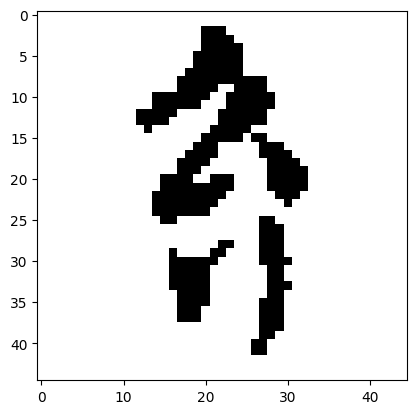

In [6]:
plt.imshow(display_transforms(total_dataset[0]["image"]).squeeze(), cmap="gray")

In [7]:
with open("suzi_umap_models.pkl", "rb") as file_handle:
    umap_models = pickle.load(file_handle)
with open("suzi_umap_embeddings.pkl", "rb") as file_handle:
    umap_embeddings = pickle.load(file_handle)

print(umap_embeddings.keys())
print(umap_embeddings["secondary_embeddings"])

dict_keys(['editions', 'annotations', 'display_images', 'gui_images', 'pitch_embeddings', 'secondary_embeddings'])
tensor([[16.2012, -1.9123],
        [ 2.7216, -6.8576],
        [ 8.4126, 18.4283],
        ...,
        [11.8643,  2.4363],
        [ 7.5157, 17.9394],
        [21.2879, -0.9236]])


/tmp/ipykernel_5632/1210589286.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_embeddings["pitch_embeddings"][:, 0], umap_embeddings["pitch_embeddings"][:, 1], s=5, c=[colors[label["pitch"]] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)


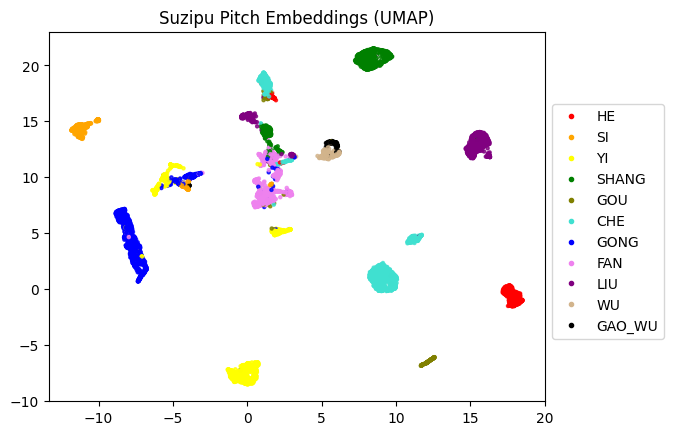

In [8]:
colors = ["red", "orange", "yellow", "green", "olive", "turquoise", "blue", "violet", "purple", "tan", "black"]
fig, ax = plt.subplots()
plt.scatter(umap_embeddings["pitch_embeddings"][:, 0], umap_embeddings["pitch_embeddings"][:, 1], s=5, c=[colors[label["pitch"]] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)
plt.title('Suzipu Pitch Embeddings (UMAP)')
custom = [plt.Line2D([], [], marker='.', color=colors[label], linestyle='None') for label in range(11)]
plt.legend(handles = custom, labels=[class_to_annotation["pitch"][label] for label in range(11)], bbox_to_anchor= (1.0, 0.15), loc= "lower left")

plt.savefig(f"suzi_pitch_umap.pdf", format="pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_5632/473489057.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_embeddings["pitch_embeddings"][:, 0], umap_embeddings["pitch_embeddings"][:, 1], s=5, c=[colors[label["pitch"]] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)


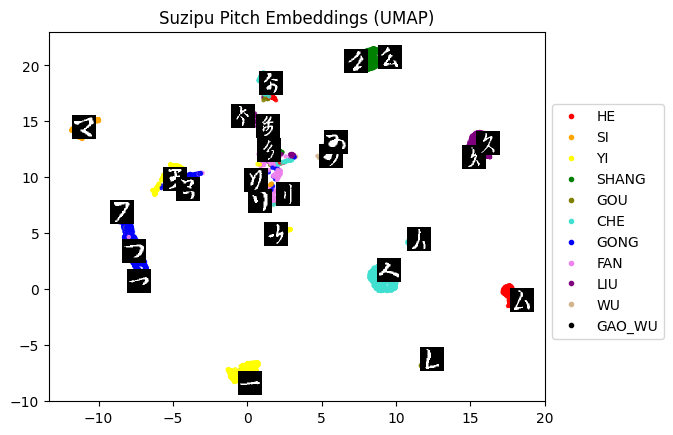

In [9]:
colors = ["red", "orange", "yellow", "green", "olive", "turquoise", "blue", "violet", "purple", "tan", "black"]
fig, ax = plt.subplots()
plt.scatter(umap_embeddings["pitch_embeddings"][:, 0], umap_embeddings["pitch_embeddings"][:, 1], s=5, c=[colors[label["pitch"]] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)
plt.title('Suzipu Pitch Embeddings (UMAP)')
custom = [plt.Line2D([], [], marker='.', color=colors[label], linestyle='None') for label in range(11)]
plt.legend(handles = custom, labels=[class_to_annotation["pitch"][label] for label in range(11)], bbox_to_anchor= (1.0, 0.15), loc= "lower left")


cmap = cm.gray
draw_indices = [
    2387, 5147, 1880, 2556, 
    5082, 4648, 3776, 1306, 913, 4102,
    5123, 2589, 3712, 5062, 5179, 
    168, 3687, # wu/gao wu
    443, 6976,
    1549, 3284, 5673, 741, 1867,
    3450
]
for idx in draw_indices:
    x, y, img = umap_embeddings["pitch_embeddings"][idx, 0], umap_embeddings["pitch_embeddings"][idx, 1], umap_embeddings["display_images"][idx]
    img = cmap(img.squeeze())
    im = OffsetImage(img, zoom=0.35)  # Adjust 'zoom' to control image size
    ab = AnnotationBbox(im, (x, y), frameon=False)  # Place image at (x, y)
    ax.add_artist(ab)

plt.savefig(f"suzi_pitch_umap_examples.pdf", format="pdf", bbox_inches="tight")
#plt.savefig(f"suzi_pitch_umap.pdf", format="pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_5632/3904800947.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_embeddings["secondary_embeddings"][:, 0], umap_embeddings["secondary_embeddings"][:, 1], s=5, c=[colors[label["secondary"]] for label in umap_embeddings["annotations"]], cmap='Spectral')
/tmp/ipykernel_5632/3904800947.py:5: UserWarning: Mismatched number of handles and labels: len(handles) = 11 len(labels) = 7
  plt.legend(handles = custom, labels=[class_to_annotation["secondary"][label] if class_to_annotation["secondary"][label] else "None" for label in range(7)], bbox_to_anchor= (1.0, 0.15), loc= "lower left")


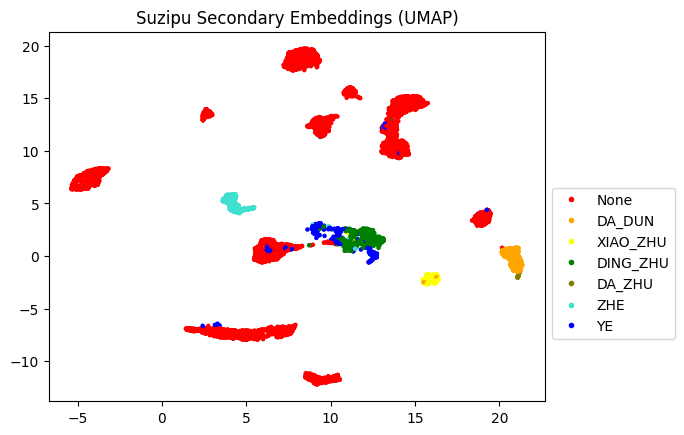

In [10]:
fig, ax = plt.subplots()
plt.scatter(umap_embeddings["secondary_embeddings"][:, 0], umap_embeddings["secondary_embeddings"][:, 1], s=5, c=[colors[label["secondary"]] for label in umap_embeddings["annotations"]], cmap='Spectral')
plt.title('Suzipu Secondary Embeddings (UMAP)')
custom = [plt.Line2D([], [], marker='.', color=colors[label], linestyle='None') for label in range(11)]
plt.legend(handles = custom, labels=[class_to_annotation["secondary"][label] if class_to_annotation["secondary"][label] else "None" for label in range(7)], bbox_to_anchor= (1.0, 0.15), loc= "lower left")
plt.savefig(f"suzi_secondary_umap.pdf", format="pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_5632/304843242.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_embeddings["secondary_embeddings"][:, 0], umap_embeddings["secondary_embeddings"][:, 1], s=5, c=[colors[label["secondary"]] for label in umap_embeddings["annotations"]], cmap='Spectral')
/tmp/ipykernel_5632/304843242.py:5: UserWarning: Mismatched number of handles and labels: len(handles) = 11 len(labels) = 7
  plt.legend(handles = custom, labels=[class_to_annotation["secondary"][label] if class_to_annotation["secondary"][label] else "None" for label in range(7)], bbox_to_anchor= (1.0, 0.15), loc= "lower left")


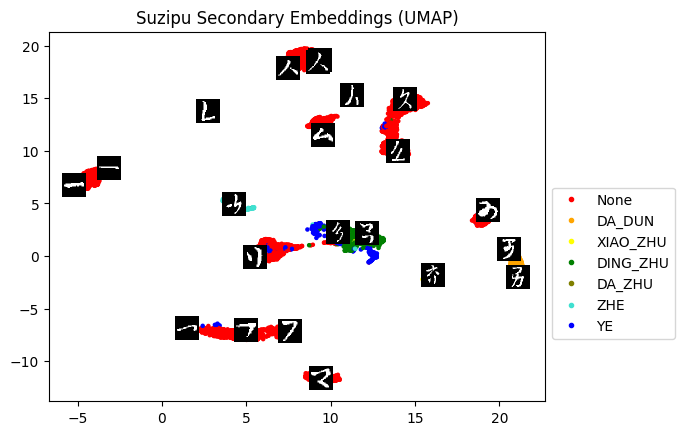

In [11]:
fig, ax = plt.subplots()
plt.scatter(umap_embeddings["secondary_embeddings"][:, 0], umap_embeddings["secondary_embeddings"][:, 1], s=5, c=[colors[label["secondary"]] for label in umap_embeddings["annotations"]], cmap='Spectral')
plt.title('Suzipu Secondary Embeddings (UMAP)')
custom = [plt.Line2D([], [], marker='.', color=colors[label], linestyle='None') for label in range(11)]
plt.legend(handles = custom, labels=[class_to_annotation["secondary"][label] if class_to_annotation["secondary"][label] else "None" for label in range(7)], bbox_to_anchor= (1.0, 0.15), loc= "lower left")

cmap = cm.gray
scaling_factor = 0.0001
draw_indices = [
    6886,
    5147, 4047, 2556, 
    2289, 5082, 4648, 3776, 
    1306, 2589, 5179,
    4992, 9, 1549, 4592,
    2596, 5307, 3832,
    6413, 293,
    3520, 1144,
]
for idx in draw_indices:
    x, y, img = umap_embeddings["secondary_embeddings"][idx, 0], umap_embeddings["secondary_embeddings"][idx, 1], umap_embeddings["display_images"][idx]
    img = cmap(img.squeeze())
    im = OffsetImage(img, zoom=0.35)  # Adjust 'zoom' to control image size
    ab = AnnotationBbox(im, (x, y), frameon=False)  # Place image at (x, y)
    ax.add_artist(ab)
plt.savefig(f"suzi_secondary_umap_examples.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [12]:
# Get nearest neighbors

from sklearn.neighbors import NearestNeighbors
pitch_nbrs = NearestNeighbors(n_neighbors=3, algorithm='ball_tree').fit(umap_embeddings["pitch_embeddings"])
pitch_distances, pitch_indices = pitch_nbrs.kneighbors([[-7, 7]])
print(pitch_indices)

secondary_nbrs = NearestNeighbors(n_neighbors=3, algorithm='ball_tree').fit(umap_embeddings["secondary_embeddings"])
secondary_distances, secondary_indices = secondary_nbrs.kneighbors([[0, -7]])
print(secondary_indices)

[[5903 6211 4405]]
[[5248  293 3912]]
